<a href="https://colab.research.google.com/github/akshithachitluri/LDA-Document-Categorization/blob/main/LDA_Document_Categorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Preprocessing: 100%|██████████| 9022/9022 [04:50<00:00, 31.01it/s]


Training LDA with 5 topics...
 → Coherence Score: 0.4825
Training LDA with 6 topics...
 → Coherence Score: 0.4695
Training LDA with 7 topics...
 → Coherence Score: 0.4925
Training LDA with 8 topics...
 → Coherence Score: 0.5286
Training LDA with 9 topics...
 → Coherence Score: 0.5417
Training LDA with 10 topics...
 → Coherence Score: 0.4998
Training LDA with 11 topics...
 → Coherence Score: 0.6124
Training LDA with 12 topics...
 → Coherence Score: 0.5309
Training LDA with 13 topics...
 → Coherence Score: 0.5543
Training LDA with 14 topics...
 → Coherence Score: 0.5657
Training LDA with 15 topics...
 → Coherence Score: 0.5422
Training LDA with 16 topics...
 → Coherence Score: 0.5248
Training LDA with 17 topics...
 → Coherence Score: 0.5202
Training LDA with 18 topics...
 → Coherence Score: 0.5425
Training LDA with 19 topics...
 → Coherence Score: 0.5094
Training LDA with 20 topics...
 → Coherence Score: 0.5330
Training LDA with 21 topics...
 → Coherence Score: 0.5130
Training LDA with 2

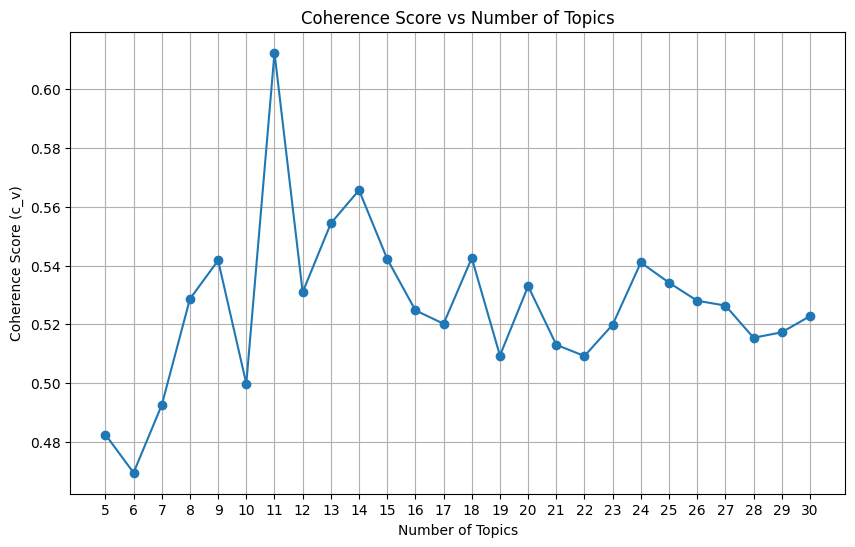

Topic 0: 0.010*"believe" + 0.007*"say" + 0.007*"jesus" + 0.006*"many" + 0.006*"mean" + 0.006*"christian" + 0.006*"claim" + 0.005*"bible"
Topic 1: 0.010*"space" + 0.007*"system" + 0.006*"research" + 0.006*"datum" + 0.006*"university" + 0.005*"launch" + 0.005*"design" + 0.005*"program"
Topic 2: 0.025*"file" + 0.018*"window" + 0.017*"program" + 0.015*"use" + 0.011*"image" + 0.010*"include" + 0.010*"version" + 0.010*"available"
Topic 3: 0.020*"drive" + 0.016*"use" + 0.014*"system" + 0.014*"card" + 0.012*"problem" + 0.011*"driver" + 0.010*"work" + 0.009*"price"
Topic 4: 0.017*"government" + 0.011*"president" + 0.010*"state" + 0.007*"public" + 0.007*"say" + 0.007*"work" + 0.007*"american" + 0.006*"right"
Topic 5: 0.017*"post" + 0.012*"entry" + 0.008*"group" + 0.008*"number" + 0.007*"list" + 0.007*"information" + 0.007*"address" + 0.007*"name"
Topic 6: 0.015*"say" + 0.013*"armenian" + 0.010*"kill" + 0.007*"armenians" + 0.007*"turkish" + 0.006*"jews" + 0.006*"live" + 0.006*"turkey"
Topic 7: 0.

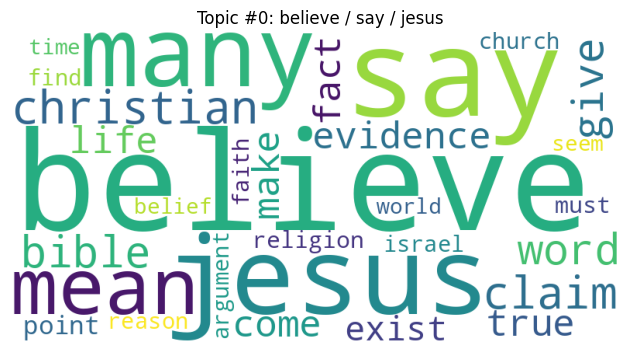

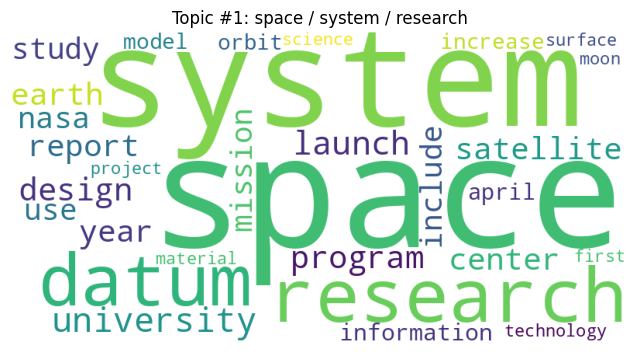

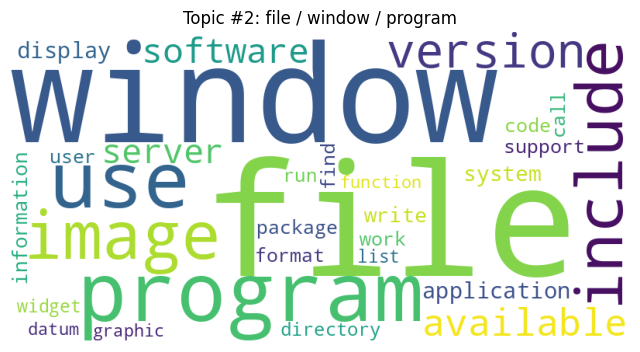

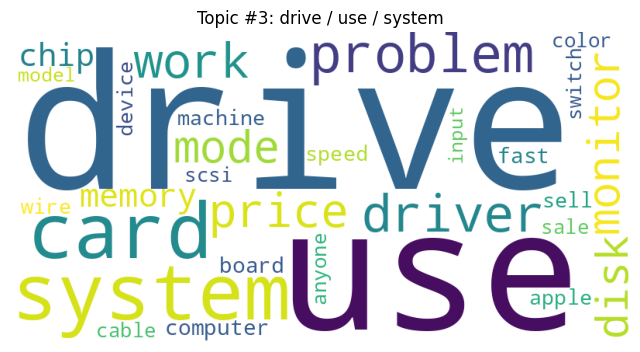

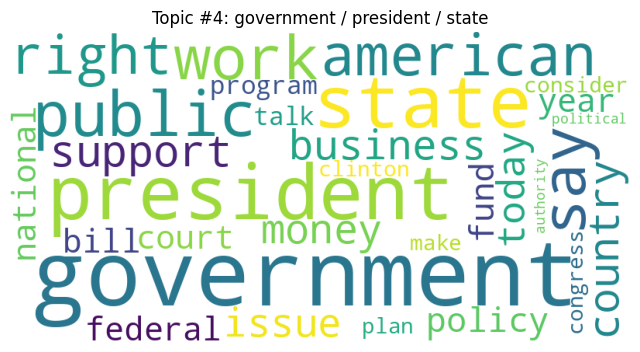

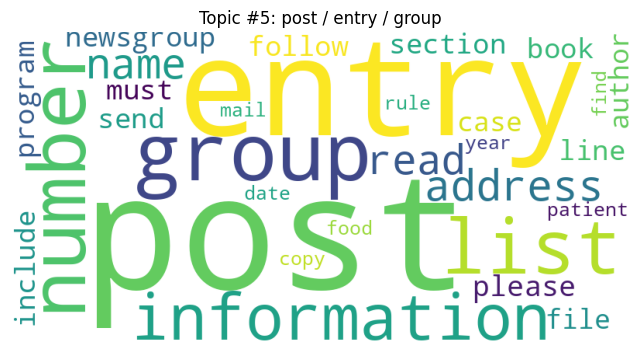

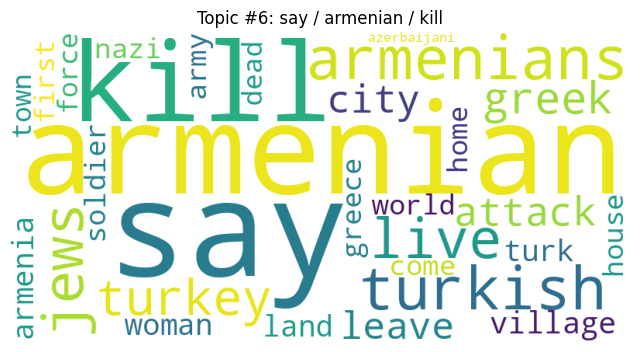

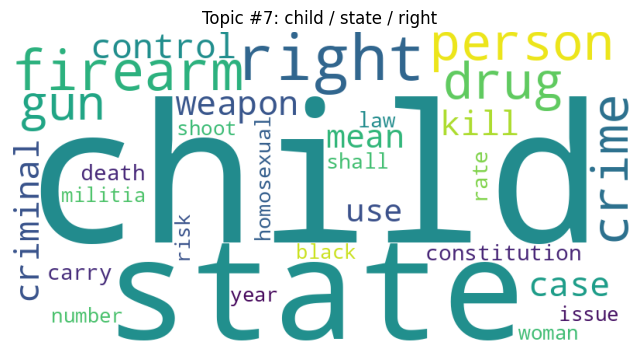

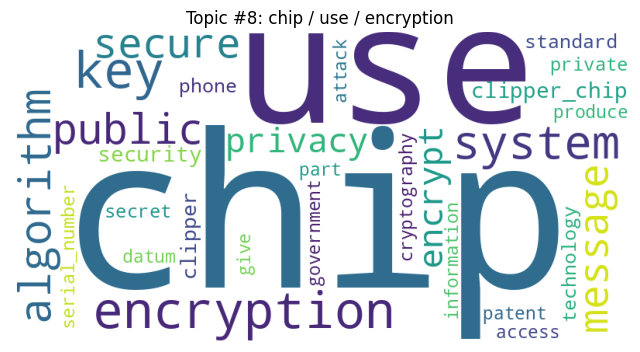

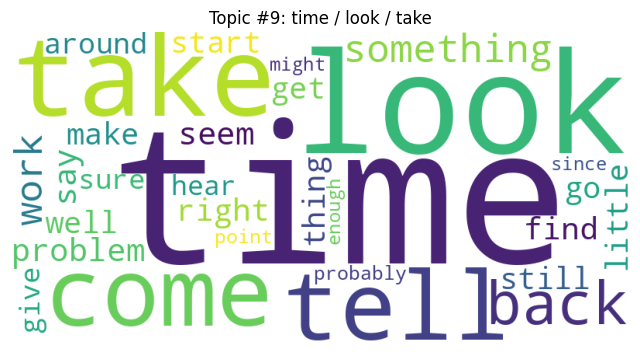

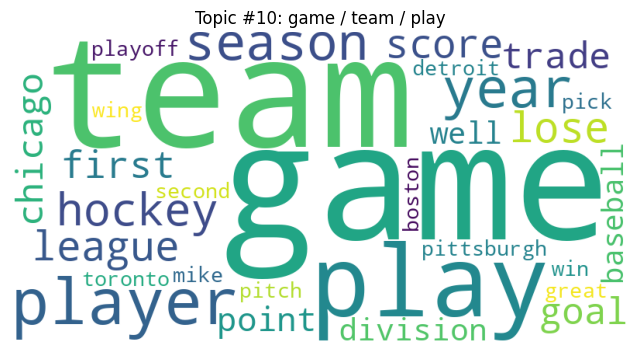

In [ ]:
try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

import spacy.cli
spacy.cli.download("en_core_web_sm")
nlp = spacy.load("en_core_web_sm")

newsgroups = fetch_20newsgroups(remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data


custom_stopwords = set(stopwords.words('english'))
custom_stopwords.update([
    'would', 'could', 'also', 'get', 'use', 'like', 'one', 'think', 'know',
    'subject', 'article', 'writes', 'thanks', 'etc', 'edu', 'com', 'org',
    'people', 'say', 'make', 'much', 'see', 'go', 'going', 'thing', 'even',
    'us', 'well', 'really', 'way', 'want', 'good', 'question', 'need'
])


def preprocess(doc):
    doc = re.sub(r'\S+@\S+', '', doc)
    doc = re.sub(r'http\S+', '', doc)
    doc = re.sub(r'\d+', '', doc)
    tokens = word_tokenize(doc.lower())
    tokens = [word for word in tokens if word.isalpha() and len(word) > 3 and word not in custom_stopwords]
    doc_spacy = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc_spacy if token.lemma_ != '-PRON-']

filtered_documents = [doc for doc in documents if len(doc) > 200 and len(doc.split()) > 20]

preprocessed_documents = []
for doc in tqdm(filtered_documents, desc="Preprocessing"):
    preprocessed_documents.append(preprocess(doc))

phrases = Phrases(preprocessed_documents, min_count=10, threshold=10)
bigram = Phraser(phrases)
bigram_docs = [bigram[doc] for doc in preprocessed_documents]


dictionary = Dictionary(bigram_docs)
dictionary.filter_extremes(no_below=15, no_above=0.4)
corpus = [dictionary.doc2bow(text) for text in bigram_docs]


best_model = None
best_coherence = 0
best_num_topics = 0
coherence_scores = []

for num_topics in range(5, 31):
    print(f"Training LDA with {num_topics} topics...")

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=20,
        iterations=500,
        chunksize=2000,
        alpha='auto',
        eta='auto',
        per_word_topics=True
    )

    cm = CoherenceModel(model=lda, texts=bigram_docs, dictionary=dictionary, coherence='c_v')
    coherence = cm.get_coherence()
    print(f" → Coherence Score: {coherence:.4f}")

    coherence_scores.append((num_topics, coherence))

    if coherence > best_coherence:
        best_model = lda
        best_coherence = coherence
        best_num_topics = num_topics


print(f"\nBest model has {best_num_topics} topics with coherence {best_coherence:.4f}")


nums, scores = zip(*coherence_scores)
plt.figure(figsize=(10, 6))
plt.plot(nums, scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs Number of Topics")
plt.xticks(nums)
plt.grid(True)
plt.show()


for i, topic in best_model.show_topics(num_topics=best_num_topics, num_words=8, formatted=True):
    print(f"Topic {i}: {topic}")


topic_names = {
    i: " / ".join([word for word, _ in best_model.show_topic(i, topn=3)])
    for i in range(best_num_topics)
}


document_topics = [
    max(topic_dist, key=lambda x: x[1])[0] if topic_dist else -1
    for topic_dist, _, _ in best_model[corpus]
]

df = pd.DataFrame({
    'document_text': filtered_documents,
    'topic_label': document_topics,
    'topic_name': [topic_names.get(label, "Unknown") for label in document_topics]
})
print("\nSample labeled documents:")
print(df.head())

best_model.save("lda_model_best.gensim")
dictionary.save("lda_dictionary_best.dict")


for t in range(best_model.num_topics):
    plt.figure(figsize=(8, 6))
    word_freq = dict(best_model.show_topic(t, 30))
    plt.imshow(WordCloud(width=800, height=400, background_color='white').fit_words(word_freq))
    plt.axis("off")
    plt.title(f"Topic #{t}: {topic_names.get(t, 'Unknown')}")
    plt.show()

vis = gensimvis.prepare(best_model, corpus, dictionary)
pyLDAvis.enable_notebook()
pyLDAvis.display(vis)